In [1]:
# uploaded = files.upload()


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

RANDOM_STATE = 55


In [3]:
df = pd.read_excel("Diagnostics.xlsx")

features = [
    'PatientAge', 'Gender', 'VentricularRate', 'AtrialRate',
    'QRSDuration', 'QTInterval', 'QTCorrected',
    'RAxis', 'TAxis', 'QRSCount'
]

df_selected = df[features + ['Rhythm', 'Beat']]
df_encoded = pd.get_dummies(df_selected, columns=['Gender'])

In [4]:
X = df_encoded.drop(columns=['Rhythm', 'Beat'])
y_rhythm = df_encoded['Rhythm']
y_beat = df_encoded['Beat']

X_temp, X_test, y_rhythm_temp, y_rhythm_test, y_beat_temp, y_beat_test = train_test_split(
    X, y_rhythm, y_beat, test_size=0.2, random_state=RANDOM_STATE)

X_train, X_val, y_rhythm_train, y_rhythm_val, y_beat_train, y_beat_val = train_test_split(
    X_temp, y_rhythm_temp, y_beat_temp, test_size=0.2, random_state=RANDOM_STATE)

In [5]:
print("\n Beat Class Distribution (Training Set):")
print(y_beat_train.value_counts(normalize=True))


 Beat Class Distribution (Training Set):
Beat
NONE                             0.508661
TWC                              0.072372
LVHV                             0.056371
STTC                             0.039342
RBBB                             0.016588
                                   ...   
LVQRSLL MIFW STTC                0.000147
ARS JEB LVQRSLL QTIE STTC VPB    0.000147
APB AQW CR LFBBB TWC TWO         0.000147
CR IVB LFBBB VEB                 0.000147
ALS AQW STTC VPB                 0.000147
Name: proportion, Length: 562, dtype: float64


In [6]:
model_rhythm = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
model_rhythm.fit(X_train, y_rhythm_train)

RandomForestClassifier(random_state=55)

In [7]:
model_beat = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=RANDOM_STATE
)

model_beat.fit(X_train, y_beat_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=55)

In [8]:
acc_rhythm_train = accuracy_score(y_rhythm_train, model_rhythm.predict(X_train))
acc_rhythm_val = accuracy_score(y_rhythm_val, model_rhythm.predict(X_val))
acc_rhythm_test = accuracy_score(y_rhythm_test, model_rhythm.predict(X_test))

acc_beat_train = accuracy_score(y_beat_train, model_beat.predict(X_train))
acc_beat_val = accuracy_score(y_beat_val, model_beat.predict(X_val))
acc_beat_test = accuracy_score(y_beat_test, model_beat.predict(X_test))

acc_rhythm_train = accuracy_score(y_rhythm_train, model_rhythm.predict(X_train))
acc_rhythm_val = accuracy_score(y_rhythm_val, model_rhythm.predict(X_val))
acc_rhythm_test = accuracy_score(y_rhythm_test, model_rhythm.predict(X_test))

J_rhythm_train = 1 - acc_rhythm_train
J_rhythm_val = 1 - acc_rhythm_val
J_rhythm_test = 1 - acc_rhythm_test

acc_beat_train = accuracy_score(y_beat_train, model_beat.predict(X_train))
acc_beat_val = accuracy_score(y_beat_val, model_beat.predict(X_val))
acc_beat_test = accuracy_score(y_beat_test, model_beat.predict(X_test))

J_beat_train = 1 - acc_beat_train
J_beat_val = 1 - acc_beat_val
J_beat_test = 1 - acc_beat_test

In [9]:
print("\n Rhythm Classification:")
print(f"  - Train Accuracy     : {acc_rhythm_train:.2%} | J_train = {J_rhythm_train:.4f}")
print(f"  - Validation Accuracy: {acc_rhythm_val:.2%} | J_cv    = {J_rhythm_val:.4f}")
print(f"  - Test Accuracy      : {acc_rhythm_test:.2%} | J_test  = {J_rhythm_test:.4f}")

print("\n Beat Classification:")
print(f"  - Train Accuracy     : {acc_beat_train:.2%} | J_train = {J_beat_train:.4f}")
print(f"  - Validation Accuracy: {acc_beat_val:.2%} | J_cv    = {J_beat_val:.4f}")
print(f"  - Test Accuracy      : {acc_beat_test:.2%} | J_test  = {J_beat_test:.4f}")


 Rhythm Classification:
  - Train Accuracy     : 100.00% | J_train = 0.0000
  - Validation Accuracy: 85.39% | J_cv    = 0.1461
  - Test Accuracy      : 85.96% | J_test  = 0.1404

 Beat Classification:
  - Train Accuracy     : 60.70% | J_train = 0.3930
  - Validation Accuracy: 53.17% | J_cv    = 0.4683
  - Test Accuracy      : 53.80% | J_test  = 0.4620


In [10]:
print("\nEnter Patient Details for Prediction:")
patient_age = float(input("Patient Age: "))
gender_input = input("Gender (MALE/FEMALE): ").strip().upper()
while gender_input not in ['MALE', 'FEMALE']:
    gender_input = input("Invalid gender. Enter 'MALE' or 'FEMALE': ").strip().upper()

ventricular_rate = float(input("Ventricular Rate: "))
atrial_rate = float(input("Atrial Rate: "))
qrs_duration = float(input("QRS Duration (sec): "))
qt_interval = float(input("QT Interval (sec): "))
qt_corrected = float(input("QT Corrected (sec): "))
r_axis = float(input("R Axis (degrees): "))
t_axis = float(input("T Axis (degrees): "))
qrs_count = int(input("QRS Count: "))

sample_input = {
    'PatientAge': patient_age,
    'Gender_FEMALE': 1 if gender_input == 'FEMALE' else 0,
    'Gender_MALE': 1 if gender_input == 'MALE' else 0,
    'VentricularRate': ventricular_rate,
    'AtrialRate': atrial_rate,
    'QRSDuration': qrs_duration,
    'QTInterval': qt_interval,
    'QTCorrected': qt_corrected,
    'RAxis': r_axis,
    'TAxis': t_axis,
    'QRSCount': qrs_count
}

sample_df = pd.DataFrame([sample_input])
sample_df = sample_df.reindex(columns=X.columns, fill_value=0)


Enter Patient Details for Prediction:


In [11]:
rhythm_probabilities = model_rhythm.predict_proba(sample_df)[0]
rhythm_classes = model_rhythm.classes_
prob_series = pd.Series(rhythm_probabilities, index=rhythm_classes)
top_4_rhythms = prob_series.nlargest(4)

In [12]:
print("\n Top 4 Predicted Rhythms and their Probabilities:")
for rhythm, prob in top_4_rhythms.items():
    print(f"  - {rhythm}: {prob:.2%}")

beat_pred = model_beat.predict(sample_df)[0]
print(f"\n Predicted Beat (most probable): {beat_pred}")


 Top 4 Predicted Rhythms and their Probabilities:
  - SB: 49.00%
  - AFIB: 31.00%
  - SR: 8.00%
  - SA: 4.00%

 Predicted Beat (most probable): NONE


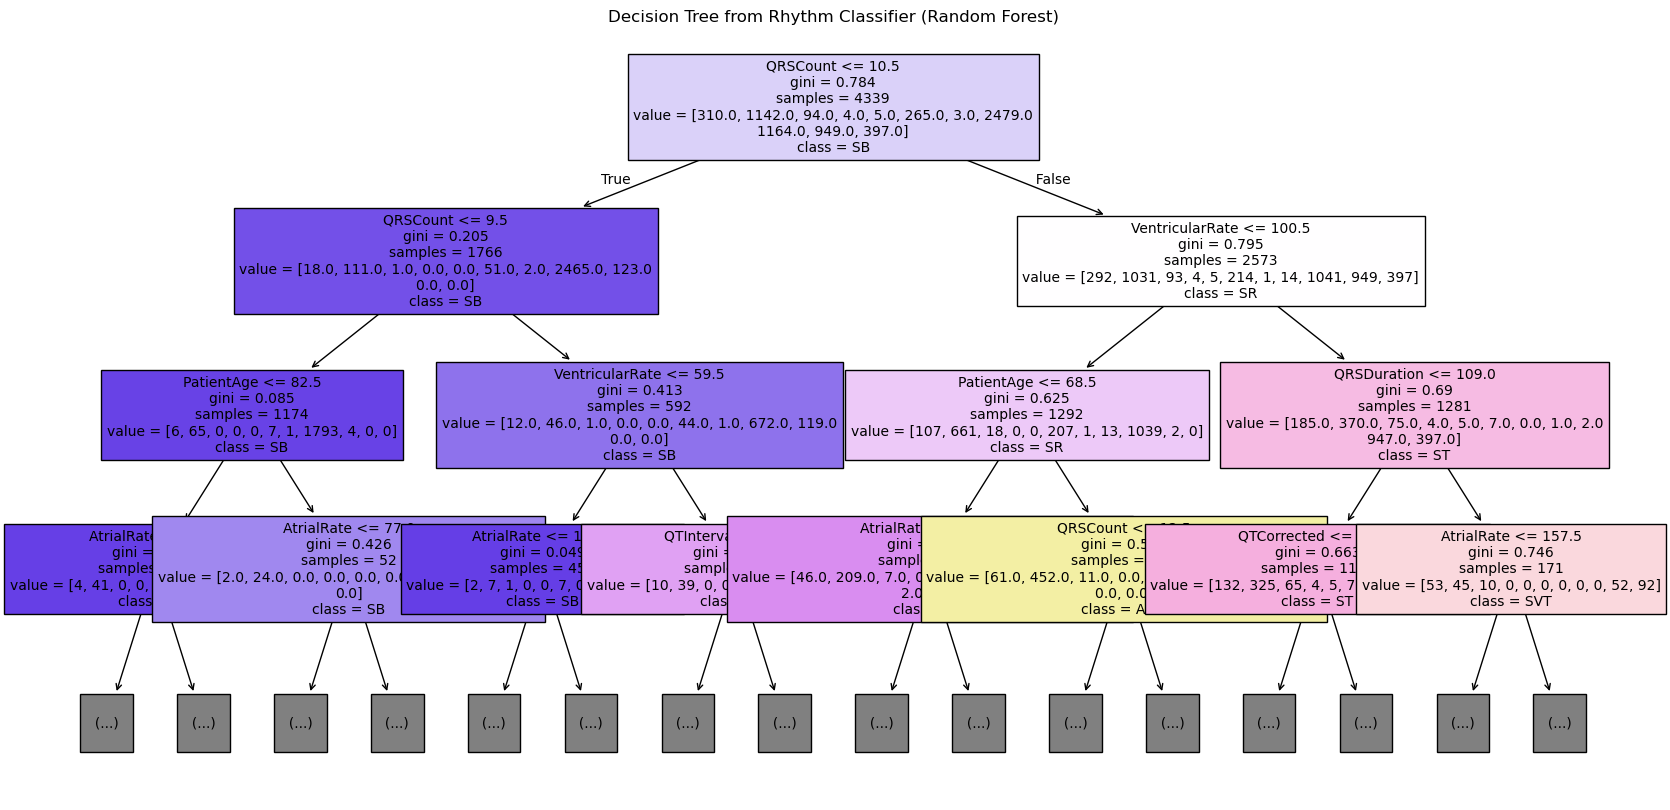

In [13]:
plt.figure(figsize=(20, 10))
plot_tree(model_rhythm.estimators_[0],
          feature_names=X.columns,
          class_names=model_rhythm.classes_.astype(str),
          filled=True,
          max_depth=3,
          fontsize=10)
plt.title("Decision Tree from Rhythm Classifier (Random Forest)")
plt.show()

In [14]:
import joblib

# After fitting model_rhythm and model_beat
joblib.dump(model_rhythm, 'rhythm_model.pkl')
joblib.dump(model_beat, 'beat_model.pkl')

print("Models saved successfully!")

Models saved successfully!
